<a href="https://colab.research.google.com/github/banteamlak1888/ML_project_2025/blob/main/Music_Genre_classification_sample__code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <h1 style='background:#C2C4E2; border:none; padding: 10px; color:blue; text-align:center'>Music Genre Classification Usig Machine Learning</h1>

<div class="list-group" id="list-tab" role="tablist">
<h1 style='background:#C2C4E2; border:none; padding: 10px; color:blue; text-align:center'>TABLE OF CONTENTS</h1>

[1. IMPORTING LIBRARIES](#1)
    
[2. LOADING DATA](#2)    

[3. DATA VISUALIZATION AND CLEANINGS](#3)     

[4. DATA PREPROCESSING](#4)     

[5. MODEL BUILDING](#5)

[6. CONCLUSION and TESTING](#6)

[7. END](#7)
    
 <a id="1"></a>
<h1 style='background:#C2C4E2; border:none; padding: 10px; color:blue; text-align:center'>LIBRARIES</h1>

In [1]:
import warnings
warnings.filterwarnings('ignore')
import os
import numpy
import pandas as pd
from tensorflow import keras
import librosa
from matplotlib import pyplot
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler,MinMaxScaler

**Points to notice:**

* There are no missing values in the dataset that we used
* Dataset includes numeric and categorical values
* Dataset is balanced

<a id="3"></a>
 <h2 style='background:#C2C4E2; border:none; padding: 10px; color:blue; text-align:center'>DATA VISUALIZATION AND CLEANING</h2>

**Steps involves in this section:**

* plot the dataset distribution in bar
* Correlation amongst numeric attributes
* feature selection and extraction using different techniques like MFCC,Chroma vector,melspectogram
* Encoding audio feature to get best important features


In [ ]:
directory = 'MyData/genres_original'
labels = ['blues','classical','country','disco','hiphop','jazz','metal','pop','reggae','rock']
features = []
labels = []

## Raw Audio Dataset Visualization Before Feature Extraction and selection

[100, 100, 100, 100, 100, 100, 100, 100, 100, 100]


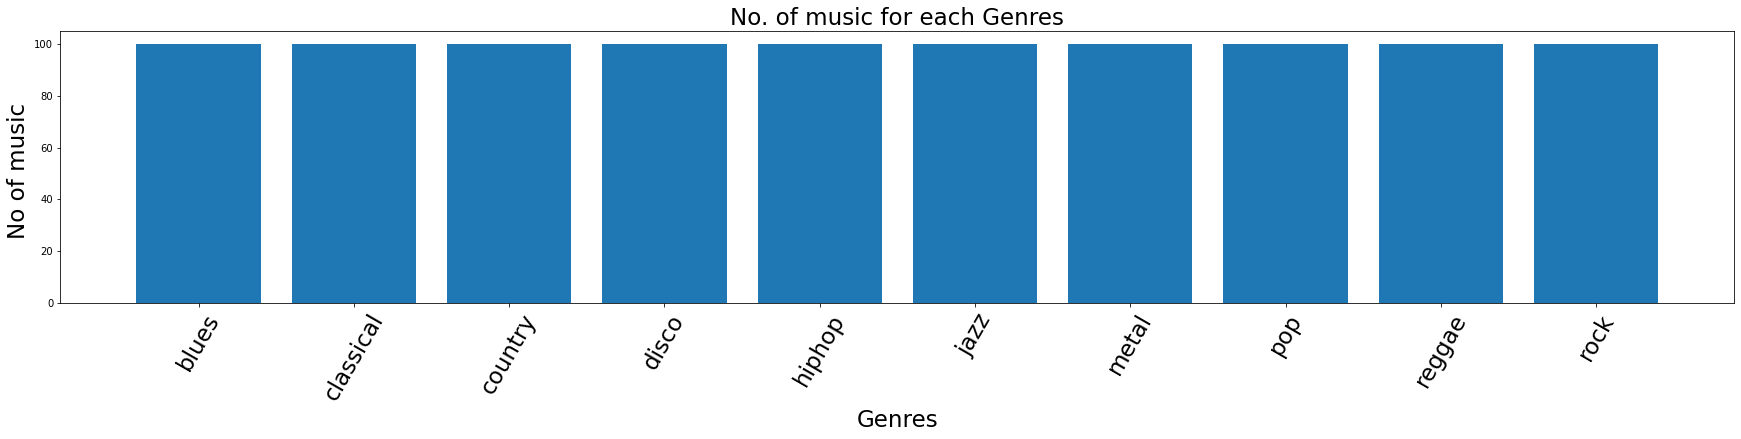

In [ ]:
labels=os.listdir(directory)
duration_of_recordings=[]
#find count of each label and plot bar graph
no_of_recordings=[]
for label in labels:
    waves = [f for f in os.listdir(directory + '/'+ label) if f.endswith('.wav')]
    no_of_recordings.append(len(waves))

#plot
plt.figure(figsize=(30,5))
index = numpy.arange(len(labels))
plt.bar(index, no_of_recordings)
print(no_of_recordings)
plt.xlabel('Genres', fontsize=23)
plt.ylabel('No of music ', fontsize=23)
plt.xticks(index, labels, fontsize=23, rotation=60)
plt.title('No. of music for each Genres',fontsize=23)
plt.show()

# Music MFCC Feature


In [ ]:
def get_mfcc(wav_file_path):#method that used to get the best features of audio using mfcc method by taking the audio pas as an arguement
    y, sr = librosa.load(wav_file_path, offset=0, duration=30)#librosa is a library that used to process audio signal
    f=librosa.feature.mfcc(y=y, sr=sr,n_mfcc=20) #librosa also has a different method for feature extraction like mfcc, melspectogram ,chromavector
    mfcc = numpy.array(f)#
    #df = pd.DataFrame(mfcc)
    #df.to_csv("Dsaet.csv")
    return mfcc

**Illustrations for how mfcc feature is extrscted and visualized**

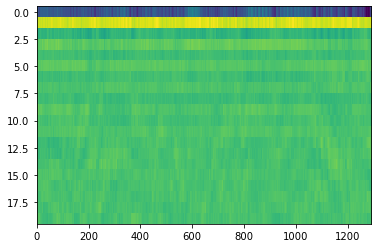

In [ ]:
example_file = "MyData/genres_original/classical/classical.00000.wav"
mfcc = get_mfcc(example_file)
pyplot.imshow(mfcc, interpolation='nearest', aspect='auto')
pyplot.show()

# Music Feature Extraction

In [ ]:
def get_feature(file_path):
    # Extracting MFCC feature
    mfcc = get_mfcc(file_path)
    mfcc_mean = mfcc.mean(axis=1)
    mfcc_min = mfcc.min(axis=1)
    mfcc_max = mfcc.max(axis=1)
    mfcc_feature = (mfcc_mean)
    feature = mfcc_feature
    return feature

# Creating CSV Music Dataset

In [ ]:
le=LabelEncoder()
labelss=le.fit_transform(labels)
labelss

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=int64)

In [ ]:
#data set preparation and preprocessing
directory = 'MyData/genres_original'
genres = ['blues','classical','country','disco','hiphop','jazz','metal','pop','reggae','rock']
features = []
labels = []
for genre in genres:
    #print("Calculating features for genre : " + genre)
    for file in os.listdir(directory+"/"+genre):
        file_path = directory+"/"+genre+"/"+file
        #print(file_path)
        features.append(get_feature(file_path))
        label = genres.index(genre)
        #print(label)
        labels.append(label)
features = numpy.array(features)
labels = numpy.array(labels)
df = pd.DataFrame(features,labels)
df.to_csv("Musicaldatasets.csv")


In [ ]:
#load the csv file that contains extracted features from the audio dataset
newdf=pd.read_csv("Musicaldatasets.csv")
newdf.head()

,Unnamed: 0,0,1,2,3,4,5,6,7,8,...,10,11,12,13,14,15,16,17,18,19
0,0,-113.619385,121.55302,-19.151056,42.345768,-6.371168,18.613033,-13.692060,15.339378,-12.283617,...,-8.322410,8.806788,-3.665802,5.745939,-5.161712,0.750298,-1.688358,-0.409329,-2.298869,1.219947
1,0,-207.581510,123.99715,8.939115,35.870758,2.919970,21.518787,-8.555368,23.355938,-10.101037,...,-5.558123,5.375942,-2.237833,4.217125,-6.011047,0.932668,-0.717028,0.292333,-0.285717,0.532144
2,0,-90.776344,140.44861,-29.100560,31.687340,-13.975973,25.741686,-13.644712,11.623112,-11.775920,...,-13.115349,5.785763,-8.899733,-1.087024,-9.216774,2.453648,-7.721793,-1.816497,-3.434354,-2.231391
3,0,-199.462000,150.09473,5.649167,26.870144,1.755441,14.236880,-4.828873,9.297849,-0.753142,...,-3.195236,6.085354,-2.476188,-1.076225,-2.876056,0.776909,-3.320056,0.637263,-0.617507,-3.406940
4,0,-160.291850,126.19576,-35.602500,22.151169,-32.487640,10.862022,-23.357162,0.500523,-11.804770,...,-13.085074,-2.809849,-6.935621,-7.559294,-9.172152,-4.510408,-5.453736,-0.924468,-4.408076,-11.701833


In [ ]:
#checking for null values
newdf.isnull().sum()
newdf.describe()


,Unnamed: 0,0,1,2,3,4,5,6,7,8,...,10,11,12,13,14,15,16,17,18,19
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,...,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,4.500000,-144.645515,99.610969,-8.937107,36.319858,-1.153185,14.634915,-5.122684,10.109182,-7.006026,...,-6.025418,4.469126,-4.798462,1.774907,-3.873035,1.151001,-3.966063,0.503959,-2.329247,-1.096681
std,2.873719,100.291076,31.423824,21.692755,16.664413,12.221879,11.841806,9.948490,10.480278,8.283634,...,6.818594,6.720293,6.171351,5.016913,4.873314,4.578993,4.550685,3.872581,3.755478,3.838176
min,0.000000,-552.106300,-1.539154,-89.896150,-18.786009,-38.915707,-28.421492,-32.945824,-24.940002,-31.656443,...,-28.050291,-15.806172,-27.549044,-12.605565,-17.545372,-15.697483,-17.235107,-11.985029,-18.505476,-19.933725
25%,2.000000,-201.152353,76.808642,-24.225841,24.145864,-9.980246,5.088530,-12.879404,1.602969,-13.263010,...,-10.972273,-0.567535,-9.365386,-1.653504,-7.162336,-1.856042,-7.201042,-2.021581,-4.672607,-3.364302
50%,4.500000,-120.354019,98.442828,-10.762060,36.995058,-0.059969,15.009363,-5.724025,9.662160,-7.584215,...,-5.918071,3.889783,-4.200263,1.878470,-3.620379,1.233307,-4.058038,0.668484,-2.387720,-1.153429
75%,7.000000,-73.922522,119.879932,5.497600,48.401813,7.908634,23.854442,2.984712,18.716546,-0.383880,...,-0.991920,9.707966,-0.157045,5.152308,-0.328690,4.347916,-0.843982,3.111888,0.151594,1.304284
max,9.000000,42.112870,193.094480,56.636234,80.692490,31.457941,45.167534,21.824984,49.023758,19.130110,...,17.423235,23.026806,13.060922,18.160437,12.356574,13.479482,11.479182,15.386705,14.691521,15.362202


### Spliting labels and features in the Dataset

In [ ]:
Y=newdf.iloc[:,[0]] # and notice here is still data frame , when you convert to the training table , please make sure adding `ravel` at the end
X=newdf.drop(Y.columns,axis = 1)
Y.head()

,Unnamed: 0
0,0
1,0
2,0
3,0
4,0


<AxesSubplot:>

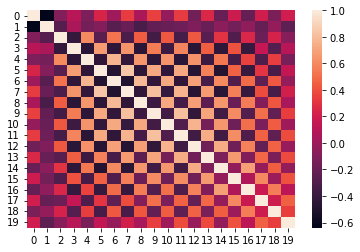

In [ ]:
import seaborn as sb
sb.heatmap(X.corr())

In [ ]:
from sklearn.exceptions import ConvergenceWarning

from warnings import simplefilter

simplefilter(action='ignore', category=ConvergenceWarning)

In [ ]:
from pandas.plotting import scatter_matrix
from matplotlib import pyplot as plt

import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense

from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_val_predict


from sklearn.preprocessing import StandardScaler

from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.neighbors import KNeighborsClassifier

from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import MultinomialNB

Using TensorFlow backend.


## Training Set & Validation Set

####  In this step we divide our  dataset into Training Set (for training the ML model) & Validation Set (for validating the performance of the trained model).
###For this I have used the train_test_split method of sklearn library.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, Y,test_size=0.2, random_state=10)
y_test.shape

(200, 1)

# Normalization  
Data normalization is used in machine learning to make model training less sensitive to the scale of features.
This allows our model to converge to better weights and, in turn, leads to a more accurate model.
We use StandardScaler of sklearn library for Normalization.

In [ ]:
from sklearn.preprocessing import MinMaxScaler #fixed import
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
#X_test #result is between 0 and 1
X_test

array([[0.63077012, 0.4684505 , 0.67910031, ..., 0.37746225, 0.59378908,
        0.51109068],
       [0.9159162 , 0.31365488, 0.63852904, ..., 0.49361552, 0.54335727,
        0.57901661],
       [0.51349701, 0.87101119, 0.47835579, ..., 0.62217257, 0.63172318,
        0.53931479],
       ...,
       [0.77498101, 0.51893974, 0.5521273 , ..., 0.61311169, 0.35008987,
        0.53664099],
       [0.7371746 , 0.5736835 , 0.73585326, ..., 0.35042556, 0.45829555,
        0.43415426],
       [0.29519793, 0.62015352, 0.59327833, ..., 0.53736518, 0.61051854,
        0.57747673]])

<font size=25, face='Times New Roman'>Dataset is Balanced</font>

Text(0.5, 1.0, 'Original Music Dataset')

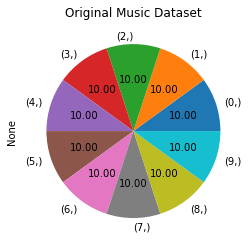

In [ ]:
sampled=Y.value_counts().plot.pie(autopct='%.2f')
sampled.set_title('Original Music Dataset')

In [ ]:
balanced_class=Y.value_counts()
#balanced_class

<a id="5"></a>
 <h2 style='background:#C2C4E2; border:none; padding: 10px; color:blue; text-align:center'>MODEL BUILDING</h2>




**Following steps are involved in the model building**

* Assining X and y the status of attributes and tags
* Splitting test and training sets
* preparing different models like KNN,SVM,LR,DT
* Initialising the neural network
* Defining by adding layers
* Compiling the neural network
* Train the neural network

In [ ]:
#designing model
models = []
models.append(('KNN',KNeighborsClassifier(n_neighbors=3)))
models.append(("RF",RandomForestClassifier(max_features= 3, min_samples_leaf=4, min_samples_split=12, n_estimators= 5)))
models.append(('LR',LogisticRegression(C=10,random_state = 0)))
models.append(('DT', DecisionTreeClassifier(criterion='entropy', max_depth=8, max_features=8,min_samples_split= 2)))

<h1><font size=25, face='Times New Roman'>1. KNN</font></h1>

In [ ]:
from sklearn import metrics
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

#K = 3
knn_clf=KNeighborsClassifier()
knn_clf.fit(X_train,y_train)
norma=MinMaxScaler()
def predict_knn(path):
    audio,sr=librosa.load(path)
    mfcc=numpy.mean(librosa.feature.mfcc(audio,sr=sr,hop_length=512,n_fft=2048).T,axis=0)

    pf = mfcc
    pff=norma.fit_transform([pf])
    pred=knn_clf.predict(pff.reshape(1,20))
    pred_value=numpy.argmax(pred)
    converted=le.inverse_transform([pred_value])
    return converted


In [ ]:
#test for unknown data
pk=predict_knn("MyData/genres_original/blues/blues.00004.wav")
#Measure The Accuracy

pre = knn_clf.predict(X_test)

from sklearn import metrics
print("Accuracy: ", round(metrics.accuracy_score(y_test, pre),2))
#print(classification_report(y_test,pre))
pk

Accuracy:  0.58


array(['blues'], dtype='<U9')

In [ ]:
#creating the learning model using KNeighborsClassifier and hyperparameters
param_grid = {'n_neighbors': list(range(1,20)),
          'weights':['uniform', 'distance'],
          'algorithm':['auto', 'ball_tree','kd_tree','brute']}
gs = GridSearchCV(knn_clf,param_grid,scoring='accuracy',refit=True)
gs.fit(X_train,y_train)
#print(gs.cv_results_['params'])


GridSearchCV(estimator=KNeighborsClassifier(),
             param_grid={'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
                         'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12,
                                         13, 14, 15, 16, 17, 18, 19],
                         'weights': ['uniform', 'distance']},
             scoring='accuracy')

In [ ]:
print("Accuracy of the tuned model: %.4f" % gs.best_score_)
print(gs.best_params_)
#gs.cv_results_['mean_test_score']
grid_predictions = gs.predict(X_test)
#print(classification_report(y_test,grid_predictions))


Accuracy of the tuned model: 0.6000
{'algorithm': 'auto', 'n_neighbors': 6, 'weights': 'distance'}


In [ ]:
path=("MyData/genres_original/blues/blues.00004.wav")
audio,sr=librosa.load(path)
mfcc=numpy.mean(librosa.feature.mfcc(audio,sr=sr,hop_length=512,n_fft=2048).T,axis=0)

pf = mfcc
pff=norma.fit_transform([pf])
pred=gs.predict(pff.reshape(1,20))
pred_value=numpy.argmax(pred)
converted=le.inverse_transform([pred_value])


In [ ]:
# Visualizing that the best K value for KNN

[0.565, 0.585, 0.61, 0.61]


Text(0, 0.5, 'Testing Accuracy')

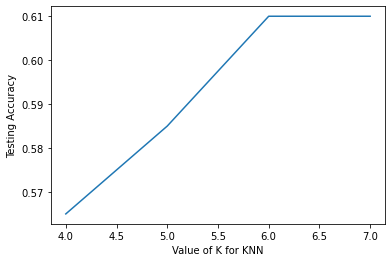

In [ ]:
scores = []
k_range = range(4, 8)
import matplotlib.pyplot as plt
for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train,y_train)
    y_pred = knn.predict(X_test)
    scores.append(metrics.accuracy_score(y_test, y_pred))

print(scores)
# allow plots to appear within the notebook
%matplotlib inline

# plot the relationship between K and testing accuracy
# plt.plot(x_axis, y_axis)
plt.plot(k_range, scores)
plt.xlabel('Value of K for KNN')
plt.ylabel('Testing Accuracy')

In [ ]:
#K_Fold X-validation
import numpy as np
nb_pred=cross_val_predict(knn,X_test, y_test)
scores_test=cross_val_score(knn,X_test, y_test, cv=10)
print("Average : ",np.mean(scores_test)*100,'%')

Average :  48.50000000000001 %


<h1><font size=25, face='Times New Roman'>2. Decision Tree</font></h1>

In [ ]:
from sklearn.tree import DecisionTreeClassifier
dt_clf = DecisionTreeClassifier(criterion="entropy", max_depth = 4,random_state=1234)
dt_clf.fit(X_train,y_train)
def predict_dt(path):
    audio,sr=librosa.load(path)
    mfcc=numpy.mean(librosa.feature.mfcc(audio,sr=sr,hop_length=512,n_fft=2048).T,axis=0)

    #pf = numpy.concatenate( (chroma_feature, mfcc) )
    pf = mfcc
    pff=norma.fit_transform([pf])
    pred=knn_clf.predict(pff.reshape(1,20))
    pred_value=numpy.argmax(pred)
    converted=le.inverse_transform([pred_value])
    return converted
pd=predict_dt("MyData/genres_original/classical/classical.00000.wav")

pre = dt_clf.predict(X_test)

from sklearn import metrics
print("Accuracy: ", round(metrics.accuracy_score(y_test, pre),2))
pd

Accuracy:  0.48


array(['blues'], dtype='<U9')

In [ ]:
#K_Fold validati
import numpy as np
nb_pred=cross_val_predict(dt_clf,X_test, y_test)
scores_test=cross_val_score(dt_clf,X_test, y_test, cv=10)
print("Average : ",np.mean(scores_test)*100,'%')

Average :  38.5 %


<h1><font size=25, face='Times New Roman'>3. SVM</font></h1>

In [ ]:
#gamma='auto', kernel='rbf'
svm_classifier=SVC(C=100, random_state=0)
svm_classifier.fit(X_train,y_train)
svm_pred=svm_classifier.predict(X_test)
print('\n****************************************************************\n')
print('Accuracy                     : ',accuracy_score(y_test,svm_pred)*100,'%')
print('________________________________________________________________\n')
print('Confusion Matrix\n')
print('',confusion_matrix(y_test,svm_pred))
print('\n****************************************************************')


****************************************************************

Accuracy                     :  65.5 %
________________________________________________________________

Confusion Matrix

 [[15  0  0  2  0  0  0  0  0  0]
 [ 0 21  0  0  0  0  0  0  1  0]
 [ 0  0 12  1  0  1  0  3  0  2]
 [ 0  0  1 10  2  0  0  5  2  0]
 [ 0  0  3  1 14  0  1  0  3  1]
 [ 1  1  3  1  0  8  0  0  1  0]
 [ 0  0  0  0  2  0 14  0  1  0]
 [ 0  1  2  0  0  0  0 18  1  0]
 [ 0  0  2  1  4  4  0  0 12  0]
 [ 1  0  2  6  2  0  1  2  1  7]]

****************************************************************


In [ ]:
#Grid search for DT
from sklearn.model_selection import GridSearchCV
param_grid = {'C': [0.1,1, 10, 100], 'gamma': [1,0.1,0.01,0.001]}
grid = GridSearchCV(SVC(),param_grid,refit=True,verbose=2)
grid.fit(X_train,y_train)
print(grid.best_estimator_)
print(classification_report(y_test,grid_predictions))

Fitting 5 folds for each of 16 candidates, totalling 80 fits
[CV] END .....................................C=0.1, gamma=1; total time=   0.0s
[CV] END .....................................C=0.1, gamma=1; total time=   0.0s
[CV] END .....................................C=0.1, gamma=1; total time=   0.0s
[CV] END .....................................C=0.1, gamma=1; total time=   0.0s
[CV] END .....................................C=0.1, gamma=1; total time=   0.0s
[CV] END ...................................C=0.1, gamma=0.1; total time=   0.0s
[CV] END ...................................C=0.1, gamma=0.1; total time=   0.1s
[CV] END ...................................C=0.1, gamma=0.1; total time=   0.0s
[CV] END ...................................C=0.1, gamma=0.1; total time=   0.0s
[CV] END ...................................C=0.1, gamma=0.1; total time=   0.0s
[CV] END ..................................C=0.1, gamma=0.01; total time=   0.0s
[CV] END ..................................C=0.1

<h1><font size=25, face='Times New Roman'>4. Naive Bayes</font></h1>

In [ ]:
from sklearn.naive_bayes import GaussianNB
nb_classifier=GaussianNB()
nb_classifier.fit(X_train,y_train)
nb_pred=nb_classifier.predict(X_test)
print('\n****************************************************************\n')
print('Accuracy                     : ',accuracy_score(y_test,nb_pred)*100,'%')
print('________________________________________________________________\n')
print('Confusion Matrix\n')
print('',confusion_matrix(y_test,nb_pred))
print('\n****************************************************************')
print(X)


****************************************************************

Accuracy                     :  43.0 %
________________________________________________________________

Confusion Matrix

 [[ 3  0  3  0  0  5  4  0  2  0]
 [ 0 17  1  0  0  1  0  0  3  0]
 [ 0  0  8  0  0  3  3  1  0  4]
 [ 0  0  0  0  0  1  7  8  1  3]
 [ 0  0  0  2  4  2  5  5  5  0]
 [ 1  1  2  0  0  4  0  2  1  4]
 [ 0  0  0  0  1  0 16  0  0  0]
 [ 0  1  0  0  0  1  0 18  2  0]
 [ 0  0  1  1  1  2  0  4 11  3]
 [ 0  0  0  0  1  2  4  8  2  5]]

****************************************************************
              0           1          2          3          4          5  \
0   -113.619385  121.553020 -19.151056  42.345768  -6.371168  18.613033   
1   -207.581510  123.997150   8.939115  35.870758   2.919970  21.518787   
2    -90.776344  140.448610 -29.100560  31.687340 -13.975973  25.741686   
3   -199.462000  150.094730   5.649167  26.870144   1.755441  14.236880   
4   -160.291850  126.195760 -35.60250

<font size=20, face='arial'>K-Fold-NB</font>

In [ ]:
nb_pred=cross_val_predict(nb_classifier,X_test, y_test)
scores_test=cross_val_score(nb_classifier,X_test, y_test, cv=10)
print("Average : ",np.mean(scores_test)*100,'%')

Average :  42.5 %


<h1><font size=25, face='Times New Roman'>4. Squential Neural Network</font></h1>

In [ ]:
from tensorflow.keras.layers import Dense,Flatten,Dropout,BatchNormalization,Conv2D,MaxPool2D
from tensorflow.keras.models import Sequential

Instructions for updating:
Call initializer instance with the dtype argument instead of passing it to the constructor
Train on 800 samples, validate on 200 samples
Epoch 1/100
800/800 [==============================] - 2s 2ms/sample - loss: 2.3884 - acc: 0.1637 - mean_absolute_error: 4.3895 - val_loss: 2.2694 - val_acc: 0.1650 - val_mean_absolute_error: 4.5420
Epoch 2/100
800/800 [==============================] - 0s 207us/sample - loss: 2.0477 - acc: 0.2575 - mean_absolute_error: 4.3895 - val_loss: 2.2366 - val_acc: 0.1800 - val_mean_absolute_error: 4.5420
Epoch 3/100
800/800 [==============================] - 0s 207us/sample - loss: 1.9162 - acc: 0.3125 - mean_absolute_error: 4.3895 - val_loss: 2.2271 - val_acc: 0.1550 - val_mean_absolute_error: 4.5420
Epoch 4/100
800/800 [==============================] - 0s 217us/sample - loss: 1.7917 - acc: 0.3475 - mean_absolute_error: 4.3895 - val_loss: 2.2324 - val_acc: 0.1500 - val_mean_absolute_error: 4.5420
Epoch 5/100
800/800 [=============

Epoch 80/100
800/800 [==============================] - 0s 160us/sample - loss: 0.8367 - acc: 0.7013 - mean_absolute_error: 4.3895 - val_loss: 1.2193 - val_acc: 0.6000 - val_mean_absolute_error: 4.5420
Epoch 81/100
800/800 [==============================] - 0s 175us/sample - loss: 0.9169 - acc: 0.6562 - mean_absolute_error: 4.3895 - val_loss: 1.0524 - val_acc: 0.6450 - val_mean_absolute_error: 4.5420
Epoch 82/100
800/800 [==============================] - 0s 275us/sample - loss: 0.8617 - acc: 0.7000 - mean_absolute_error: 4.3895 - val_loss: 1.0772 - val_acc: 0.6250 - val_mean_absolute_error: 4.5420
Epoch 83/100
800/800 [==============================] - 0s 138us/sample - loss: 0.9127 - acc: 0.6762 - mean_absolute_error: 4.3895 - val_loss: 1.0838 - val_acc: 0.6350 - val_mean_absolute_error: 4.5420
Epoch 84/100
800/800 [==============================] - 0s 155us/sample - loss: 0.8612 - acc: 0.6775 - mean_absolute_error: 4.3895 - val_loss: 0.9999 - val_acc: 0.6700 - val_mean_absolute_erro

KeyError: 'MAE'

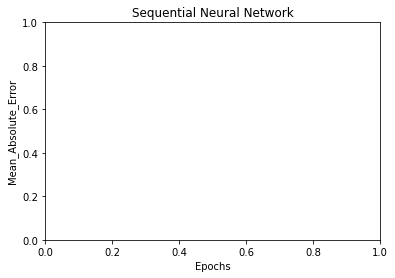

In [ ]:
model=Sequential([
    Flatten(input_shape=(20,)),
    Dense(100,activation="relu"),
    Dropout(0.2),
    BatchNormalization(),
    Dense(100,activation="relu"),
    Dropout(0.2),
    BatchNormalization(),
    Dense(100,activation="relu"),
    Dropout(0.2),
    BatchNormalization(),
    Dense(100,activation="relu"),

    #output layer
    Dense(10,activation="softmax")

])

model.compile(loss="sparse_categorical_crossentropy",optimizer="rmsprop",metrics=['accuracy','MAE'])
history=model.fit(X_train,y_train,validation_data=(X_test,y_test),epochs=100)
model.evaluate(X_test,y_test)

plt.xlabel('Epochs')
plt.ylabel('Mean_Absolute_Error')
plt.title('Sequential Neural Network')
plt.plot(history.history['MAE'])


In [ ]:
def predicts(path):
    audio,sr=librosa.load(path)
    mfcc=numpy.mean(librosa.feature.mfcc(audio,sr=sr,hop_length=512,n_fft=2048).T,axis=0)

    #pf = numpy.concatenate( (chroma_feature, mfcc) )
    pf = mfcc
    pff=norma.fit_transform([pf])
    pred=model.predict(pff.reshape(1,20))
    pred_value=numpy.argmax(pred)
    converted=le.inverse_transform([pred_value])
    return converted

In [ ]:
file_label = predicts("MyData/genres_original/classical/classical.00054.wav")
file_label

NameError: name 'predicts' is not defined

# <a id="6"></a>
 <h2 style='background:#C2C4E2; border:none; padding: 10px; color:blue; text-align:center'>Conclusion and Testing</h2>

**Concluding the model with:**

* Testing on the test set
* Evaluating the confusion matrix
* Evaluating the classification report

# <h1 style='background:#C2C4E2; border:none; padding: 10px; color:blue; text-align:center'>END</h1>